# Basic Autoencoder
### https://github.com/rasbt/deeplearning-models/blob/master/pytorch_ipynb/autoencoder/ae-basic.ipynb

# 1. System (file config, args, gpu)

In [1]:
import time
import numpy as np
import torch

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('Device:', device)


Device: cuda:0


# 2. Dataset

In [3]:
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

batch_size = 256
# Note transforms.ToTensor() scales input images
# to 0-1 range
train_dataset = datasets.MNIST(root='dataset', 
                               train=True, 
                               transform=transforms.ToTensor(),
                               download=True)
test_dataset = datasets.MNIST(root='dataset', 
                              train=False, 
                              transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, 
                          batch_size=batch_size, 
                          shuffle=True)
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)

# Checking the dataset
for images, labels in train_loader:  
    print('Image batch dimensions:', images.shape)
    print('Image label dimensions:', labels.shape)
    break

Image batch dimensions: torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])


# 3. Model

In [4]:
import torch
import torch.nn.functional as F

class Autoencoder(torch.nn.Module):

    def __init__(self, num_features):
        super(Autoencoder, self).__init__()
        
        ### ENCODER
        self.linear_1 = torch.nn.Linear(num_features, num_hidden_1)
        # The following to lones are not necessary, 
        # but used here to demonstrate how to access the weights
        # and use a different weight initialization.
        # By default, PyTorch uses Xavier/Glorot initialization, which
        # should usually be preferred.
        self.linear_1.weight.detach().normal_(0.0, 0.1)
        self.linear_1.bias.detach().zero_()
        
        ### DECODER
        self.linear_2 = torch.nn.Linear(num_hidden_1, num_features)
        self.linear_2.weight.detach().normal_(0.0, 0.1)
        self.linear_2.bias.detach().zero_()
        

    def forward(self, x):
        
        ### ENCODER
        encoded = self.linear_1(x)
        encoded = F.leaky_relu(encoded)
        
        ### DECODER
        logits = self.linear_2(encoded)
        decoded = torch.sigmoid(logits)
        
        return decoded

In [ ]:
# Hyperparameters
random_seed = 123
learning_rate = 0.005
num_epochs = 5

# Architecture
num_features = 784
num_hidden_1 = 32

torch.manual_seed(random_seed)
model = Autoencoder(num_features=num_features)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  

# 4. Train

In [5]:
start_time = time.time()
for epoch in range(num_epochs):
    for batch_idx, (features, targets) in enumerate(train_loader):
        
        # don't need labels, only the images (features)
        features = features.view(-1, 28*28).to(device)
            
        ### FORWARD AND BACK PROP
        decoded = model(features)
        cost = F.binary_cross_entropy(decoded, features)
        optimizer.zero_grad()
        
        cost.backward()
        
        ### UPDATE MODEL PARAMETERS
        optimizer.step()
        
        ### LOGGING
        if not batch_idx % 50:
            print ('Epoch: %03d/%03d | Batch %03d/%03d | Cost: %.4f' 
                   %(epoch+1, num_epochs, batch_idx, 
                     len(train_loader), cost))
            
    print('Time elapsed: %.2f min' % ((time.time() - start_time)/60))
    
print('Total Training Time: %.2f min' % ((time.time() - start_time)/60))

Epoch: 001/005 | Batch 000/235 | Cost: 0.7044
Epoch: 001/005 | Batch 050/235 | Cost: 0.2175
Epoch: 001/005 | Batch 100/235 | Cost: 0.1657
Epoch: 001/005 | Batch 150/235 | Cost: 0.1419
Epoch: 001/005 | Batch 200/235 | Cost: 0.1320
Time elapsed: 0.10 min
Epoch: 002/005 | Batch 000/235 | Cost: 0.1242
Epoch: 002/005 | Batch 050/235 | Cost: 0.1155
Epoch: 002/005 | Batch 100/235 | Cost: 0.1116
Epoch: 002/005 | Batch 150/235 | Cost: 0.1060
Epoch: 002/005 | Batch 200/235 | Cost: 0.1058
Time elapsed: 0.18 min
Epoch: 003/005 | Batch 000/235 | Cost: 0.1041
Epoch: 003/005 | Batch 050/235 | Cost: 0.1036
Epoch: 003/005 | Batch 100/235 | Cost: 0.1007
Epoch: 003/005 | Batch 150/235 | Cost: 0.0974
Epoch: 003/005 | Batch 200/235 | Cost: 0.0986
Time elapsed: 0.26 min
Epoch: 004/005 | Batch 000/235 | Cost: 0.1003
Epoch: 004/005 | Batch 050/235 | Cost: 0.0979
Epoch: 004/005 | Batch 100/235 | Cost: 0.1010
Epoch: 004/005 | Batch 150/235 | Cost: 0.0993
Epoch: 004/005 | Batch 200/235 | Cost: 0.0946
Time elapse

# 5. Evaluation

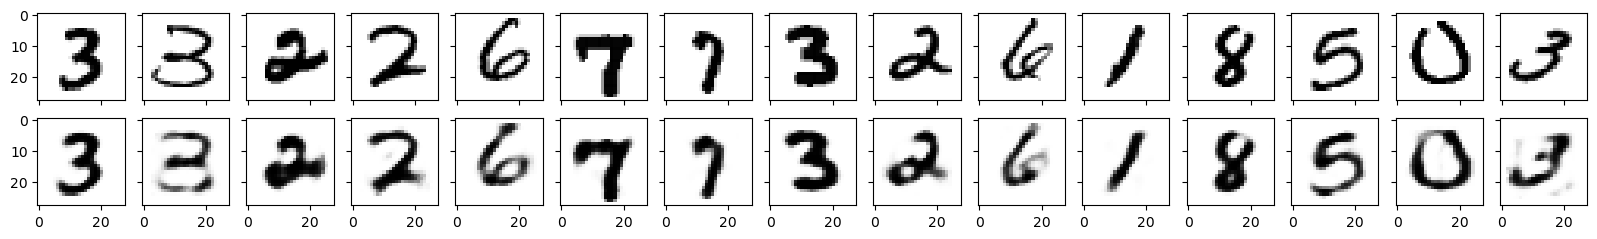

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

n_images = 15
image_width = 28

fig, axes = plt.subplots(nrows=2, ncols=n_images, 
                         sharex=True, sharey=True, figsize=(20, 2.5))
orig_images = features[:n_images]
decoded_images = decoded[:n_images]

for i in range(n_images):
    for ax, img in zip(axes, [orig_images, decoded_images]):
        curr_img = img[i].detach().to(torch.device('cpu'))
        ax[i].imshow(curr_img.view((image_width, image_width)), cmap='binary')